# 草稿 — LangGraph 開發/重構 workflow 長什麼樣（僅畫圖，不實作內部細節）

**這是什麼**：部門在討論用 LangGraph 做一個「開發 agent」，取代日常開發/重構裡瑣碎的部分——
人只負責「需求對齊」跟「階段性驗證方向對不對」，中間 multi-agent coding、測試、code review
全部交給 graph 自己跑完，沒問題才 `git push` / 開 MR。

這份 notebook **只畫出這個 graph 長什麼樣**（節點是空殼，回傳假資料），目的是先看架構合不合理，
不是要交付的實作。它借用課程既有幾章教過的機制拼起來，對照關係列在最後一個 markdown cell。

平行開發那段加了三層(對應討論時提到的「vertical slice 分工 → Touches 宣告初篩 → worktree
實體隔離執行」)：

1. **`plan_slices`** — 依可獨立驗收的功能垂直切 slice，每個 slice 宣告自己會動到的檔案範圍
   （`touches`），不是按部門/模組/任務類型硬分類。
2. **`plan_waves`** — 純程式邏輯（不問 LLM）依 `touches` 有沒有交集把 slice 分波：同一波保證
   互不重疊，才值得平行；有交集的自動被分進不同波，序列執行。
3. **`dispatch_wave` → `code_agent` → `merge_wave`** — 同一波的 slice 各自在專屬 worktree
   平行做完（sketch 不接真的 worktree，只示意這一步的職責），做完依序合併；合併衝突就走
   `resolve_conflict`（示意成回頭重派同一波），沒衝突就用 `advance_or_finish` 判斷還有沒有
   下一波。

> 不需要 API key，節點都是純 Python 假邏輯，離線就能跑完、也能看到互動迴圈長怎樣。

In [2]:
import fnmatch
import operator
import sys
from typing import Annotated, Literal, TypedDict

sys.path.insert(0, ".")
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.config import get_store
from langgraph.graph import END, START, StateGraph
from langgraph.store.memory import InMemoryStore
from langgraph.types import Command, Send, interrupt

from _graph_viz import show_graph

## State

`code_changes` 用 `operator.add` 當 reducer，因為同一波裡多個平行的 `code_agent`
各自寫回自己那一份，需要合併而不是互相覆蓋（跟 04 章 `Send` 那個 fan-out 範例的
`summaries: Annotated[list[str], operator.add]` 是同一招）。`slices`/`waves`/`current_wave`
是這次新增的三層平行邏輯要用的欄位。

In [3]:
class DevWorkflowState(TypedDict):
    requirement: str
    slices: list[dict]        # [{"id": "...", "touches": ["glob", ...]}]
    waves: list[list[str]]    # 分波結果：每一波是一組 slice id，同一波互不重疊
    current_wave: int
    code_changes: Annotated[list[str], operator.add]
    test_report: str
    review_report: str


class SliceTask(TypedDict):
    id: str
    touches: list[str]

## 節點

- `align_requirements`：人 ⇄ agent 對齊需求。用 `get_store()` 讀「上一輪人工回饋」——
  這是跨 thread 的長期記憶（11 章），不是這次對話內的訊息 history。
- `plan_slices` / `plan_waves`：上面說的第 1、2 層——垂直切 slice、宣告 touches、
  純程式邏輯分波。
- `dispatch_wave` / `code_agent` / `merge_wave` / `resolve_conflict` / `advance_or_finish`：
  第 3 層——同一波平行做完（`Send`，04 章）、合併、衝突就重派、沒衝突就判斷還有沒有下一波。
- `test_agent` / `review_agent`：兩個平行的驗證視角，互不干擾（呼應 `npspo-coding-workflow-setup`
  harness：test 跟 review 本來就該是獨立維度）。
- `human_checkpoint`：`interrupt()` 暫停（07 章），等人確認方向對不對；`reject` 的話把
  理由存進 `store`，下一輪 `align_requirements` 讀得到，不是船過水無痕。
- `push_or_mr`：通過人工確認才真的動手。

實務上 `code_agent` 這裡會透過 MCP tools（13 章）呼叫專案自己的開發工具（git、lint、跑測試），
而不是內嵌 shell 指令——這份草稿不碰這塊。

In [4]:
def align_requirements(state: DevWorkflowState, config: RunnableConfig) -> dict:
    store = get_store()
    thread_id = config["configurable"]["thread_id"]
    feedback = store.get(("workflow", thread_id), "last_feedback")

    requirement = state.get("requirement") or "（示意）需求描述"
    if feedback:
        requirement += f"（依上一輪回饋調整：{feedback.value['reason']}）"

    return {"requirement": requirement}


def plan_slices(state: DevWorkflowState) -> dict:
    # 示意：slice-A 跟 slice-C 故意宣告同一個 touches，等一下分波時會被拆開，
    # 不是因為它們「屬於同一個模組/類型」而綁在一起或拆開。
    slices = [
        {"id": "slice-A", "touches": ["src/api/**"]},
        {"id": "slice-B", "touches": ["src/ui/**"]},
        {"id": "slice-C", "touches": ["src/api/**"]},
    ]
    return {"slices": slices, "code_changes": []}


def plan_waves(state: DevWorkflowState) -> dict:
    # 純程式邏輯分波，不問 LLM：touches 有交集的 slice 一定不同波。
    # 這裡用簡單的字串相等判斷示意；harness 的 inner-loop.js 用的是真正的 glob 交集演算法。
    slices = state["slices"]
    waves: list[list[str]] = []
    for s in slices:
        for wave in waves:
            overlaps = any(
                fnmatch.fnmatch(t, other_t) or fnmatch.fnmatch(other_t, t)
                for other_id in wave
                for other_t in next(x["touches"] for x in slices if x["id"] == other_id)
                for t in s["touches"]
            )
            if not overlaps:
                wave.append(s["id"])
                break
        else:
            waves.append([s["id"]])
    return {"waves": waves, "current_wave": 0}


def dispatch_wave(state: DevWorkflowState) -> dict:
    return {}  # no-op 節點，純粹當 fan-out 的掛點，真正的分派邏輯在下面的 conditional edge


def fanout_current_wave(state: DevWorkflowState) -> list[Send]:
    wave = state["waves"][state["current_wave"]]
    slice_by_id = {s["id"]: s for s in state["slices"]}
    return [Send("code_agent", slice_by_id[sid]) for sid in wave]


def code_agent(state: SliceTask) -> dict:
    return {"code_changes": [f"{state['id']} 已完成（示意，實務上在獨立 worktree 裡跑）"]}


def merge_wave(state: DevWorkflowState) -> Command[Literal["resolve_conflict", "advance_or_finish"]]:
    # 依序把這一波每個 slice 的分支 merge 回主工作目錄，跑一次合併驗證。
    # 這裡示意成永遠成功；真的失敗要走 resolve_conflict（git merge --abort +
    # git revert -m 1 撤掉已合併成功的，整波降級成序列重做）。
    conflict = False  # 這份 sketch 不模擬真的合併衝突
    return Command(goto="resolve_conflict" if conflict else "advance_or_finish")


def resolve_conflict(state: DevWorkflowState) -> Command[Literal["dispatch_wave"]]:
    return Command(goto="dispatch_wave")  # 示意：真實邏輯是降級成序列重做，這裡簡化成重派同一波


def advance_or_finish(state: DevWorkflowState) -> Command[Literal["dispatch_wave", "test_agent", "review_agent"]]:
    # 純布林判斷：這一波過了，還有沒有下一波。有就繼續分波跑，沒有才進驗證階段。
    next_wave = state["current_wave"] + 1
    if next_wave < len(state["waves"]):
        return Command(update={"current_wave": next_wave}, goto="dispatch_wave")
    return Command(goto=["test_agent", "review_agent"])


def test_agent(state: DevWorkflowState) -> dict:
    return {"test_report": "PASS（示意）"}


def review_agent(state: DevWorkflowState) -> dict:
    return {"review_report": "PASS（示意）"}


def human_checkpoint(
    state: DevWorkflowState, config: RunnableConfig
) -> Command[Literal["align_requirements", "push_or_mr"]]:
    store = get_store()
    thread_id = config["configurable"]["thread_id"]

    decision = interrupt(
        {
            "code_changes": state["code_changes"],
            "test_report": state["test_report"],
            "review_report": state["review_report"],
            "ask": "方向對嗎？resume 一個 dict：{'approve': True} 或 {'approve': False, 'reason': ...}",
        }
    )

    if decision.get("approve"):
        return Command(goto="push_or_mr")

    store.put(("workflow", thread_id), "last_feedback", {"reason": decision.get("reason", "")})
    return Command(goto="align_requirements")


def push_or_mr(state: DevWorkflowState) -> dict:
    return {}

## 組圖

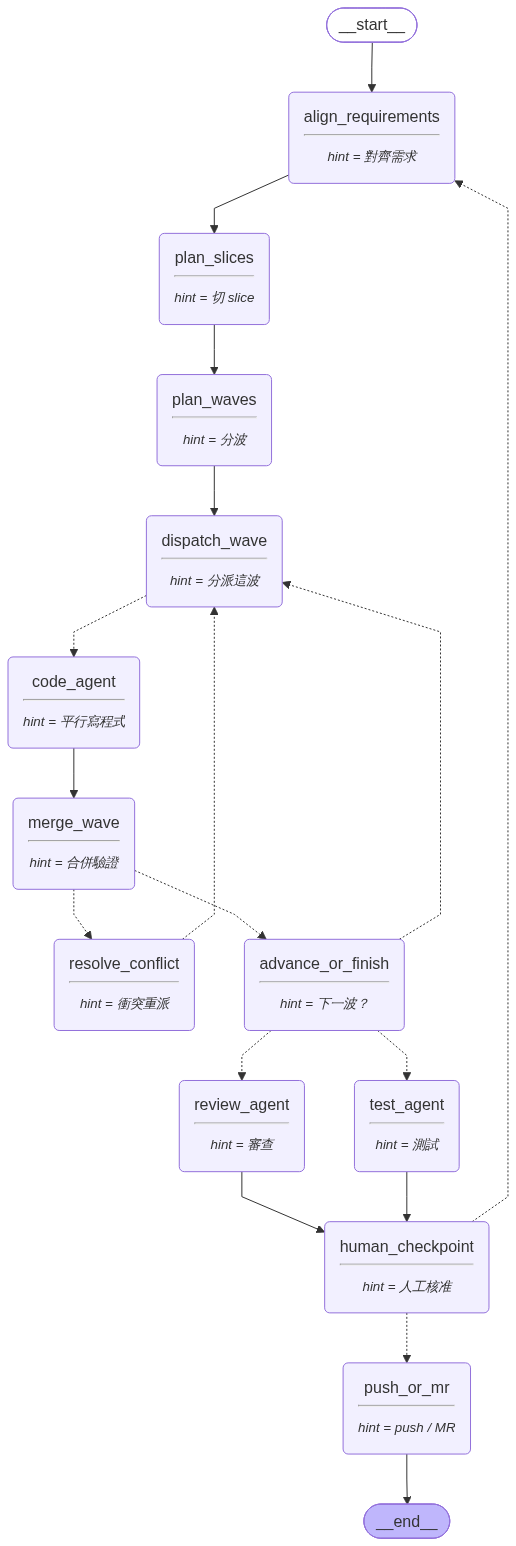

In [5]:
# add_node 的 metadata 會被 show_graph 畫進節點框框裡（一條 <hr/> 分隔線下面的小字），
# 不用另外拉一份中文對照表——圖本身就看得懂每個節點在做什麼。key 故意留空字串：
# langchain_core 的渲染邏輯固定印成「key = value」，空字串 key 就只剩「= 提示文字」，
# 不會多印一個「提示」標籤字樣。
# 另外，提示故意寫得很短：mermaid.ink 的畫圖 API 是把整份 mermaid 語法塞進 GET 網址裡，
# 每個節點都掛一整句中文說明會讓網址長度爆掉，圖直接 404（畫不出來，不是語法錯）。
builder = StateGraph(DevWorkflowState)
builder.add_node("align_requirements", align_requirements, metadata={"hint": "對齊需求"})
builder.add_node("plan_slices", plan_slices, metadata={"hint": "切 slice"})
builder.add_node("plan_waves", plan_waves, metadata={"hint": "分波"})
builder.add_node("dispatch_wave", dispatch_wave, metadata={"hint": "分派這波"})
builder.add_node("code_agent", code_agent, metadata={"hint": "平行寫程式"})
builder.add_node("merge_wave", merge_wave, metadata={"hint": "合併驗證"})
builder.add_node("resolve_conflict", resolve_conflict, metadata={"hint": "衝突重派"})
builder.add_node("advance_or_finish", advance_or_finish, metadata={"hint": "下一波？"})
builder.add_node("test_agent", test_agent, metadata={"hint": "測試"})
builder.add_node("review_agent", review_agent, metadata={"hint": "審查"})
builder.add_node("human_checkpoint", human_checkpoint, metadata={"hint": "人工核准"})
builder.add_node("push_or_mr", push_or_mr, metadata={"hint": "push / MR"})

builder.add_edge(START, "align_requirements")
builder.add_edge("align_requirements", "plan_slices")
builder.add_edge("plan_slices", "plan_waves")
builder.add_edge("plan_waves", "dispatch_wave")
builder.add_conditional_edges("dispatch_wave", fanout_current_wave, ["code_agent"])
builder.add_edge("code_agent", "merge_wave")
builder.add_edge("test_agent", "human_checkpoint")
builder.add_edge("review_agent", "human_checkpoint")
builder.add_edge("push_or_mr", END)

graph = builder.compile(checkpointer=InMemorySaver(), store=InMemoryStore())
show_graph(graph)

## 跑一輪：先被打回去重對齊一次，再核准過關

示意「有問題 → 重新對齊需求」跟「沒問題 → push/MR」這兩條路都真的走得通，
中間也真的分了兩波（slice-A/B 同波，slice-C 因為 touches 跟 slice-A 重疊被分到第二波）。

In [6]:
config = {"configurable": {"thread_id": "demo-1"}}

state = graph.invoke({"requirement": "", "code_changes": []}, config)
print("分波結果：", state["waves"])
print("第一次卡在 human_checkpoint：", state["__interrupt__"][0].value)

state = graph.invoke(Command(resume={"approve": False, "reason": "review 覺得 slice-B 沒處理邊界情況"}), config)
print("\n打回去重對齊之後，需求變成：", state["requirement"])
print("再次卡在 human_checkpoint：", state["__interrupt__"][0].value)

final_state = graph.invoke(Command(resume={"approve": True}), config)
print("\n核准後跑到底，沒有 __interrupt__ 了:", "__interrupt__" not in final_state)

分波結果： [['slice-A', 'slice-B'], ['slice-C']]
第一次卡在 human_checkpoint： {'code_changes': ['slice-A 已完成（示意，實務上在獨立 worktree 裡跑）', 'slice-B 已完成（示意，實務上在獨立 worktree 裡跑）', 'slice-C 已完成（示意，實務上在獨立 worktree 裡跑）'], 'test_report': 'PASS（示意）', 'review_report': 'PASS（示意）', 'ask': "方向對嗎？resume 一個 dict：{'approve': True} 或 {'approve': False, 'reason': ...}"}

打回去重對齊之後，需求變成： （示意）需求描述（依上一輪回饋調整：review 覺得 slice-B 沒處理邊界情況）
再次卡在 human_checkpoint： {'code_changes': ['slice-A 已完成（示意，實務上在獨立 worktree 裡跑）', 'slice-B 已完成（示意，實務上在獨立 worktree 裡跑）', 'slice-C 已完成（示意，實務上在獨立 worktree 裡跑）', 'slice-A 已完成（示意，實務上在獨立 worktree 裡跑）', 'slice-B 已完成（示意，實務上在獨立 worktree 裡跑）', 'slice-C 已完成（示意，實務上在獨立 worktree 裡跑）'], 'test_report': 'PASS（示意）', 'review_report': 'PASS（示意）', 'ask': "方向對嗎？resume 一個 dict：{'approve': True} 或 {'approve': False, 'reason': ...}"}

核准後跑到底，沒有 __interrupt__ 了: True


## 跟既有章節/skill 的對照

| 這張圖裡的機制 | 對應 |
|---|---|
| `plan_slices` 宣告 `touches`、`plan_waves` 用純程式邏輯分波 | 呼應 `npspo-coding-workflow-setup` harness 的 `Depends:`/`Touches:` 分波邏輯 |
| `Send` 動態展開同一波的平行 `code_agent` | 04 章控制流 |
| `merge_wave` → `resolve_conflict` 的合併/降級迴圈 | 呼應 harness 用 git worktree 隔離 + `git revert -m 1` 降級序列重做 |
| `interrupt()` + `Command(goto=...)` 的人工核准迴圈 | 07 章 human-in-the-loop |
| `Command` 路由（節點自己決定下一站，含一次 fan-out 給多個節點） | 04 / 09 章 |
| `checkpointer=InMemorySaver()`，同一 `thread_id` 能中斷、resume | 06 / 07 章 |
| `store=InMemoryStore()` 跨輪記住人工回饋（不是這次對話的訊息，是長期記憶） | 11 章 |
| `test_agent`/`review_agent` 平行跑、各自唯讀判斷 | 呼應 harness 的多視角 reviewer 設計 |
| `code_agent` 實際落地時呼叫 git/lint/測試工具 | 13 章 MCP tools（這份草稿沒接，只留位置） |

**這張草圖故意簡化、但正式做的話要想清楚的地方**：
- `plan_waves` 這裡用簡單字串交集判斷 touches 重不重疊；harness 用的是真正的 glob 交集演算法，
  精確度差很多（例如 `src/api/**` 跟 `src/api/user.py` 這種包含關係，字串交集判斷不出來）。
- `resolve_conflict` 簡化成「回頭重派同一波」；harness 的實際做法是整波降級成序列逐一重做，
  而且用 `git revert -m 1` 而不是 `reset --hard`，因為工作目錄可能有這次改動前就存在、
  跟這次無關的未提交內容，`reset --hard` 會連那些一起洗掉。
- `code_agent` 目前是單輪空殼，實務上每個 slice 大概率也要一個「重試 + 收斂判斷」的子迴圈
  （不能讓 LLM 自己決定「還要不要再試」，harness 那份文件裡吃過這個虧）。
- `human_checkpoint` 現在是唯一的人工關卡；要不要在 `push_or_mr` 前再加一道範圍/密鑰掃描之類
  的機械檢查，看部門對「自動 push」的風險胃口。